In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

In [ ]:
# -----------------------------
# Load Monte Carlo results
# -----------------------------
csv_path = "../outputs/20250725_hazard_iter_1000/percolation_overall_results.csv"

df = pd.read_csv(csv_path)

# Basic sanity check
required_cols = [
    "fail_iter",
    "load_served_ratio",
    "voltage_violations",
    "line_overload_violations",
    "powerflow_success"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only convergent power flow runs
df_valid = df[df["powerflow_success"] == True].copy()

print(f"Total MC iterations: {len(df)}")
print(f"Convergent iterations: {len(df_valid)}")

Total MC iterations: 1000
Convergent iterations: 619


In [3]:
def compute_convergence_stats(values):
    """
    Compute running mean and 95% confidence interval.

    Parameters
    ----------
    values : 1D numpy array
        Metric values from MC simulations (only valid runs)

    Returns
    -------
    n : array
        Sample size at each step
    mean : array
        Running mean
    ci_low : array
        Lower bound of 95% CI
    ci_high : array
        Upper bound of 95% CI
    """
    values = np.asarray(values)
    n = np.arange(1, len(values) + 1)

    running_mean = np.cumsum(values) / n

    running_se = np.array([
        sem(values[:i], nan_policy="omit") if i > 1 else 0.0
        for i in n
    ])

    ci_low = running_mean - 1.96 * running_se
    ci_high = running_mean + 1.96 * running_se

    return n, running_mean, ci_low, ci_high

In [4]:
metrics = {
    "load_served_ratio": "Served load ratio",
    "voltage_violations": "Voltage violations",
    "line_overload_violations": "Line overload violations"
}

results = {}

for col, label in metrics.items():
    vals = df_valid[col].values
    results[col] = compute_convergence_stats(vals)

Saved ../figures/mc_convergence_check/convergence_load_served_ratio.png
Saved ../figures/mc_convergence_check/convergence_voltage_violations.png
Saved ../figures/mc_convergence_check/convergence_line_overload_violations.png


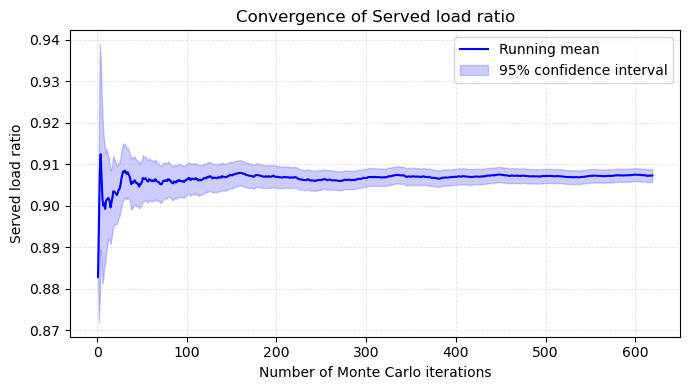

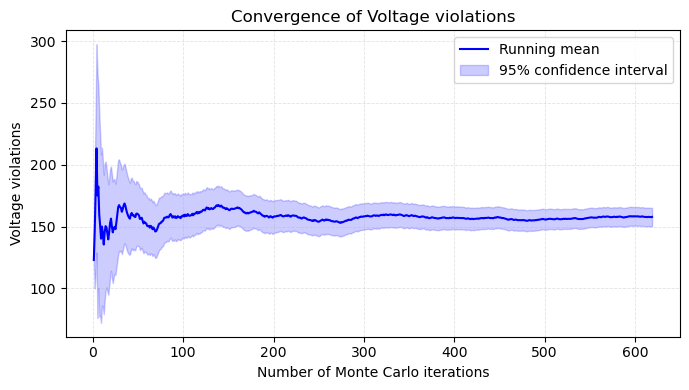

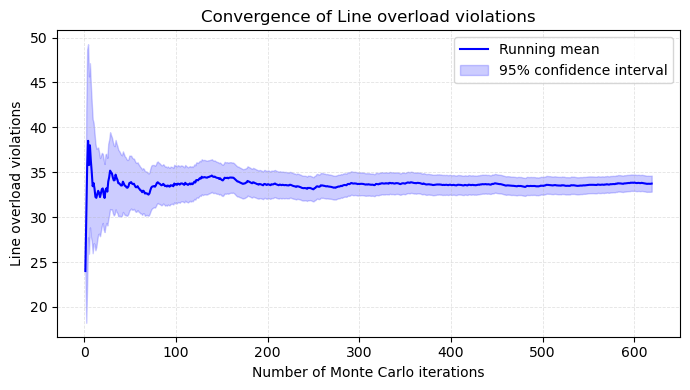

In [19]:
for col, label in metrics.items():
    n, mean, ci_low, ci_high = results[col]

    plt.figure(figsize=(7, 4))
    plt.plot(n, mean, label="Running mean", color="blue")
    plt.fill_between(
        n, ci_low, ci_high,
        color="blue", alpha=0.2,
        label="95% confidence interval"
    )

    plt.xlabel("Number of Monte Carlo iterations")
    plt.ylabel(label)
    plt.title(f"Convergence of {label}")
    plt.legend()
    plt.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )
    plt.tight_layout()

    out_name = f"../figures/mc_convergence_check/convergence_{col}.png"
    plt.savefig(out_name, dpi=600)
    # plt.close()

    print(f"Saved {out_name}")

Saved convergence_all_metrics.png


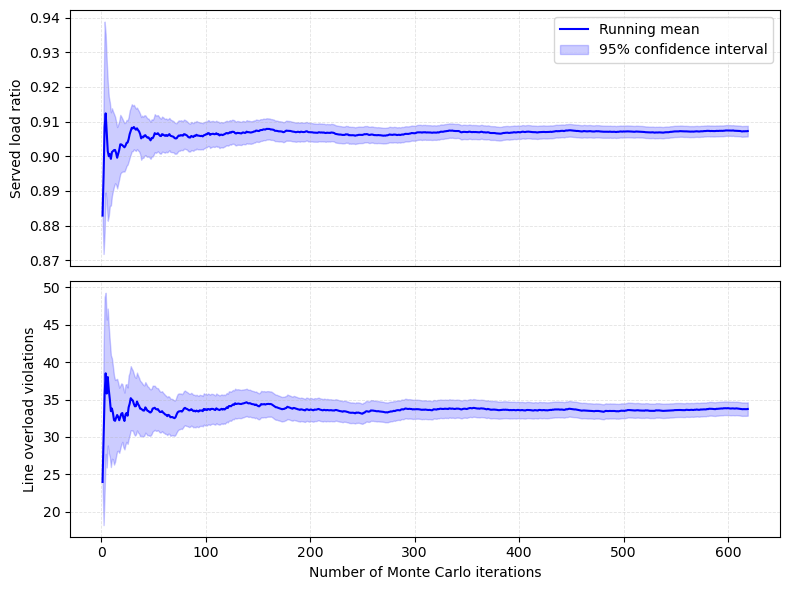

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 6),
    sharex=True
)

metrics_order = [
    ("load_served_ratio", "Served load ratio"),
    ("line_overload_violations", "Line overload violations"),
]

for i, (ax, (col, label)) in enumerate(zip(axes, metrics_order)):
    n, mean, ci_low, ci_high = results[col]

    ax.plot(n, mean, color="blue", label="Running mean")
    ax.fill_between(
        n,
        ci_low,
        ci_high,
        color="blue",
        alpha=0.2,
        label="95% confidence interval"
    )

    ax.set_ylabel(label)
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )
    if i < len(axes) - 1:
        ax.tick_params(
            axis="x",
            which="both",
            bottom=False,
            top=False,
            labelbottom=False
        )

# 只在最下面一张图显示 x 轴
axes[-1].set_xlabel("Number of Monte Carlo iterations")

# 只放一个 legend（放在最上面那张图里）
axes[0].legend(loc="best")

plt.tight_layout()
plt.savefig("../figures/mc_convergence_check/convergence_all_metrics.png", dpi=300)

print("Saved convergence_all_metrics.png")